# Sentiment–valence best-direction alignment

This read-only exploration compares the frozen best-layer **mean-difference** and **one-dimensional DAS** directions from two source experiments:

- sentiment directions trained on ToyMovieReview: `2026-09-18_20-22_CDT`;
- valence directions trained on full AIT: `2026-09-23_09-10_CDT`.

For GPT-2 Small and Qwen3-0.6B Base, it computes within-sentiment, within-valence, and valence-versus-sentiment cosine matrices. It saves signed cosine for orientation-aware comparison and absolute cosine for axis alignment. No model weights or datasets are downloaded, and no direction or layer is refitted or reselected.

## Scientific boundary

Both source runs use negative-to-positive direction orientation, so signed cosine is interpretable. Absolute cosine measures alignment of the underlying one-dimensional axes. The selected layers can differ across representation and method; residual streams share a model coordinate space, but a cosine between different boundaries is still a cross-layer geometric diagnostic—not evidence that the model uses a single causal mechanism.

In [1]:
# --------------------------- User settings ---------------------------
PROJECT_URL = "https://github.com/Adefioye/sentiment-manifold.git"
PROJECT_REVISION = None  # Optional commit or tag. Existing checkouts must match it.
CONFIG_RELATIVE_PATH = "configs/sentiment_valence_direction_alignment.yaml"

DRIVE_STORAGE_ROOT = "/content/drive/MyDrive/sentiment-geometry"
TIMEZONE_NAME = "America/Chicago"
RESUME_RUN_ID = None
RUN_ANALYSIS = True

## 1. Install and verify the project

The notebook delegates checkpoint validation, cosine computation, persistence, and plotting to reusable package APIs.

In [2]:
import importlib
import os
import pkgutil
import subprocess
import sys
from pathlib import Path

PROJECT_ROOT = Path("/content/sentiment-manifold")
if not (PROJECT_ROOT / ".git").is_dir():
    subprocess.run(["git", "clone", PROJECT_URL, str(PROJECT_ROOT)], check=True)
else:
    print(f"Reusing {PROJECT_ROOT}")
project_commit = subprocess.check_output(
    ["git", "rev-parse", "HEAD"], cwd=PROJECT_ROOT, text=True
).strip()
if PROJECT_REVISION is not None:
    expected_commit = subprocess.check_output(
        ["git", "rev-parse", PROJECT_REVISION], cwd=PROJECT_ROOT, text=True
    ).strip()
    if project_commit != expected_commit:
        raise RuntimeError(
            f"Existing checkout is {project_commit}, expected {expected_commit}. "
            "Use a fresh runtime or update PROJECT_REVISION."
        )
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-e", f"{PROJECT_ROOT}[notebooks]"],
    check=True,
)
os.chdir(PROJECT_ROOT)
project_root_string = str(PROJECT_ROOT.resolve())
if project_root_string in sys.path:
    sys.path.remove(project_root_string)
sys.path.insert(0, project_root_string)
for loaded_name in list(sys.modules):
    if loaded_name == "sentiment_geometry" or loaded_name.startswith("sentiment_geometry."):
        del sys.modules[loaded_name]
importlib.invalidate_caches()

import sentiment_geometry
expected_package_root = (PROJECT_ROOT / "sentiment_geometry").resolve()
imported_package_root = Path(sentiment_geometry.__file__).resolve().parent
if imported_package_root != expected_package_root:
    raise ImportError(
        f"Imported sentiment_geometry from {imported_package_root}, "
        f"expected {expected_package_root}. Restart the runtime and rerun from the top."
    )
module_names = sorted(
    module.name
    for module in pkgutil.walk_packages(sentiment_geometry.__path__, prefix="sentiment_geometry.")
    if module.name != "sentiment_geometry.__main__"
)
for module_name in module_names:
    importlib.import_module(module_name)
required_apis = {
    "sentiment_geometry.analysis": {
        "DirectionAlignmentConfig", "run_direction_alignment_analysis"
    },
    "sentiment_geometry.reporting": {"plot_direction_alignment"},
    "sentiment_geometry.persistence": {
        "RunArtifactStore", "maybe_mount_google_drive", "prepare_timestamped_run"
    },
}
for module_name, api_names in required_apis.items():
    module = importlib.import_module(module_name)
    missing_apis = sorted(name for name in api_names if not hasattr(module, name))
    if missing_apis:
        raise ImportError(f"{module_name} is missing {missing_apis}.")
print("Project commit:", project_commit)
print("Imported package from:", imported_package_root)

Project commit: 043644711c634c38dcb586ecab44739ba27c7548
Imported package from: /content/sentiment-manifold/sentiment_geometry


## 2. Mount Drive and configure the exploration

The source runs are opened read-only. Tables and figures are written under a separate `sentiment-valence-direction-alignment` run. This analysis is CPU-only.

In [3]:
import json

import pandas as pd
from IPython.display import display

from sentiment_geometry.analysis import DirectionAlignmentConfig
from sentiment_geometry.persistence import (
    RunArtifactStore, maybe_mount_google_drive, prepare_timestamped_run
)

maybe_mount_google_drive(True)
config = DirectionAlignmentConfig.load(PROJECT_ROOT / CONFIG_RELATIVE_PATH)
SOURCE_ROOTS = {
    source.name: source.run_root(DRIVE_STORAGE_ROOT) for source in config.sources
}
SOURCE_STATUSES = {}
for source_name, source_root in SOURCE_ROOTS.items():
    manifest_path = source_root / "run_manifest.json"
    if not manifest_path.is_file():
        raise FileNotFoundError(manifest_path)
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    SOURCE_STATUSES[source_name] = manifest.get("status")
if "RUN_LAYOUT" not in globals() or RESUME_RUN_ID is not None:
    RUN_LAYOUT = prepare_timestamped_run(
        DRIVE_STORAGE_ROOT,
        experiment_name=config.output_experiment_name,
        timezone_name=TIMEZONE_NAME,
        resume_run_id=RESUME_RUN_ID,
    )
RunArtifactStore(RUN_LAYOUT.root).write_json("requested_config.json", config.to_dict())
RUN_LAYOUT.update_manifest(
    status="configured",
    metadata={
        "project_commit": project_commit,
        "source_runs": {
            source.name: source.run_id for source in config.sources
        },
        "models": [model.name for model in config.models],
        "methods": config.methods,
        "configuration": "requested_config.json",
    },
)
display(pd.DataFrame([
    {
        "representation": source.name,
        "run_id": source.run_id,
        "selection_dataset": source.selection_dataset,
        "locked_evaluation_dataset": source.evaluation_dataset,
        "manifest_status": SOURCE_STATUSES[source.name],
        "run_root": SOURCE_ROOTS[source.name],
    }
    for source in config.sources
]))
print("Alignment run ID:  ", RUN_LAYOUT.run_id)
print("Alignment run root:", RUN_LAYOUT.root)

Mounted at /content/drive


,representation,run_id,selection_dataset,locked_evaluation_dataset,manifest_status,run_root
0,sentiment,2026-09-18_20-22_CDT,toy_adverbs,sst,completed,/content/drive/MyDrive/sentiment-geometry/sent...
1,valence,2026-09-23_09-10_CDT,ait_eval,ait_test,resumed,/content/drive/MyDrive/sentiment-geometry/full...


Alignment run ID:   2026-09-24_09-15_CDT
Alignment run root: /content/drive/MyDrive/sentiment-geometry/sentiment-valence-direction-alignment/runs/2026-09-24_09-15_CDT


## 3. Load frozen checkpoints and compute alignment

The analysis validates the selection CSV, locked-evaluation layer, artifact identity, model revision, one-dimensional shape, unit norm, and negative-to-positive orientation before calculating any cosine.

In [4]:
from sentiment_geometry.analysis import run_direction_alignment_analysis

if not RUN_ANALYSIS:
    print("Analysis execution is disabled. Set RUN_ANALYSIS = True.")
else:
    try:
        RUN_LAYOUT.update_manifest(status="running")
        alignment = run_direction_alignment_analysis(
            config,
            storage_root=DRIVE_STORAGE_ROOT,
            output_dir=RUN_LAYOUT.results_dir,
        )
        RUN_LAYOUT.update_manifest(status="analysis-completed")
    except BaseException as error:
        RUN_LAYOUT.update_manifest(
            status="failed", metadata={"failure_type": type(error).__name__}
        )
        raise
    print("Saved analysis tables to:", alignment.output_dir)

Saved analysis tables to: /content/drive/MyDrive/sentiment-geometry/sentiment-valence-direction-alignment/runs/2026-09-24_09-15_CDT/results


## 4. Audit and display the selected directions

There must be exactly one frozen direction for every representation × model × method cell. The same-method table is the direct sentiment-versus-valence comparison; the full cross matrices below also show whether a valence direction from one method aligns with the sentiment direction from the other method.

In [9]:
from itertools import product

MODEL_ORDER = [model.name for model in config.models]
METHOD_ORDER = list(config.methods)
REPRESENTATION_ORDER = ["sentiment", "valence"]
selections = alignment.selected_directions.copy()
similarities = alignment.similarities.copy()
same_method = alignment.same_method_alignment.copy()
selection_keys = ["representation", "model", "method"]
expected_selections = set(product(REPRESENTATION_ORDER, MODEL_ORDER, METHOD_ORDER))
actual_selections = set(selections[selection_keys].itertuples(index=False, name=None))
if expected_selections != actual_selections:
    raise RuntimeError(
        f"Incomplete selection grid. Missing={sorted(expected_selections - actual_selections)}"
    )
if selections.duplicated(selection_keys).any():
    raise RuntimeError("Duplicate selected directions were loaded.")
if not selections["unit_norm"].between(0.99999, 1.00001).all():
    raise RuntimeError("A selected direction is not unit norm.")
if not selections["checkpoint_path"].map(lambda value: Path(value).is_file()).all():
    raise FileNotFoundError("A selected checkpoint disappeared during analysis.")
expected_similarity_rows = len(MODEL_ORDER) * 3 * len(METHOD_ORDER) ** 2
if len(similarities) != expected_similarity_rows:
    raise RuntimeError(
        f"Expected {expected_similarity_rows} cosine rows; found {len(similarities)}."
    )
if len(same_method) != len(MODEL_ORDER) * len(METHOD_ORDER):
    raise RuntimeError("The same-method cross-representation table is incomplete.")

MODEL_LABELS = {"gpt2-small": "GPT-2 Small", "qwen-0.6b": "Qwen3-0.6B Base"}
METHOD_LABELS = {"mean_diff": "Mean Difference", "das": "DAS (1D)"}
selected_display = selections.copy()
selected_display["layer_and_score"] = selected_display.apply(
    lambda row: f"L{int(row['selected_layer']):02d} ({float(row['selection_value_percent']):.1f}%)",
    axis=1,
)
selected_table = selected_display.pivot_table(
    index=["representation", "method"],
    columns="model",
    values="layer_and_score",
    aggfunc="first",
).reindex(columns=MODEL_ORDER)
selected_table.columns = [MODEL_LABELS[model] for model in MODEL_ORDER]
display(selected_table.style.set_caption("Frozen layer (selection logit-flip %)"))

same_method_display = same_method.copy()
same_method_display["alignment"] = same_method_display.apply(
    lambda row: (
        f"{float(row['signed_cosine']):+.3f} signed / "
        f"{float(row['absolute_cosine']):.3f} absolute "
        f"(V:L{int(row['valence_layer']):02d}, S:L{int(row['sentiment_layer']):02d})"
    ),
    axis=1,
)
same_method_table = same_method_display.pivot(
    index="method", columns="model", values="alignment"
).reindex(index=METHOD_ORDER, columns=MODEL_ORDER)
same_method_table.index = [METHOD_LABELS[method] for method in METHOD_ORDER]
same_method_table.columns = [MODEL_LABELS[model] for model in MODEL_ORDER]
display(same_method_table.style.set_caption("Valence versus sentiment: same-method alignment"))

,GPT-2 Small,Qwen3-0.6B Base
Mean Difference,"+0.443 signed / 0.443 absolute (V:L11, S:L10)","+0.384 signed / 0.384 absolute (V:L28, S:L23)"
DAS (1D),"+0.466 signed / 0.466 absolute (V:L11, S:L10)","+0.481 signed / 0.481 absolute (V:L26, S:L26)"


## 5. Display the three cosine-matrix families

Rows and columns include each direction's selected residual boundary. The cross-representation matrices place valence directions on rows and sentiment directions on columns.

In [10]:
from IPython.display import Markdown

COMPARISON_LABELS = {
    "within_sentiment": "Sentiment directions",
    "within_valence": "Valence directions",
    "valence_vs_sentiment": "Valence versus sentiment directions",
}
for comparison, comparison_label in COMPARISON_LABELS.items():
    for model_name in MODEL_ORDER:
        subset = similarities[
            (similarities["comparison"] == comparison)
            & (similarities["model"] == model_name)
        ]
        display(Markdown(f"### {comparison_label} — {MODEL_LABELS[model_name]}"))
        for metric in ("signed_cosine", "absolute_cosine"):
            table = subset.pivot(
                index=["row_method", "row_layer"],
                columns=["column_method", "column_layer"],
                values=metric,
            )
            display(Markdown(f"**{metric.replace('_', ' ').title()}**"))
            display(table.style.format("{:.3f}"))

### Sentiment directions — GPT-2 Small

**Signed Cosine**

,column_method,mean_diff,das
,column_layer,10,10
row_method,row_layer,,
das,10,0.856,1.000
mean_diff,10,1.000,0.856


**Absolute Cosine**

,column_method,mean_diff,das
,column_layer,10,10
row_method,row_layer,,
das,10,0.856,1.000
mean_diff,10,1.000,0.856


...

### Valence versus sentiment directions — Qwen3-0.6B Base

**Signed Cosine**

,column_method,mean_diff,das
,column_layer,23,26
row_method,row_layer,,
das,26,0.503,0.481
mean_diff,28,0.384,0.425


**Absolute Cosine**

,column_method,mean_diff,das
,column_layer,23,26
row_method,row_layer,,
das,26,0.503,0.481
mean_diff,28,0.384,0.425


## 6. Save and display alignment heatmaps

Six figures are produced: signed and absolute cosine versions of sentiment-only, valence-only, and valence-versus-sentiment alignment. Each figure contains separate GPT-2 and Qwen panels.

### Signed Cosine Within Sentiment

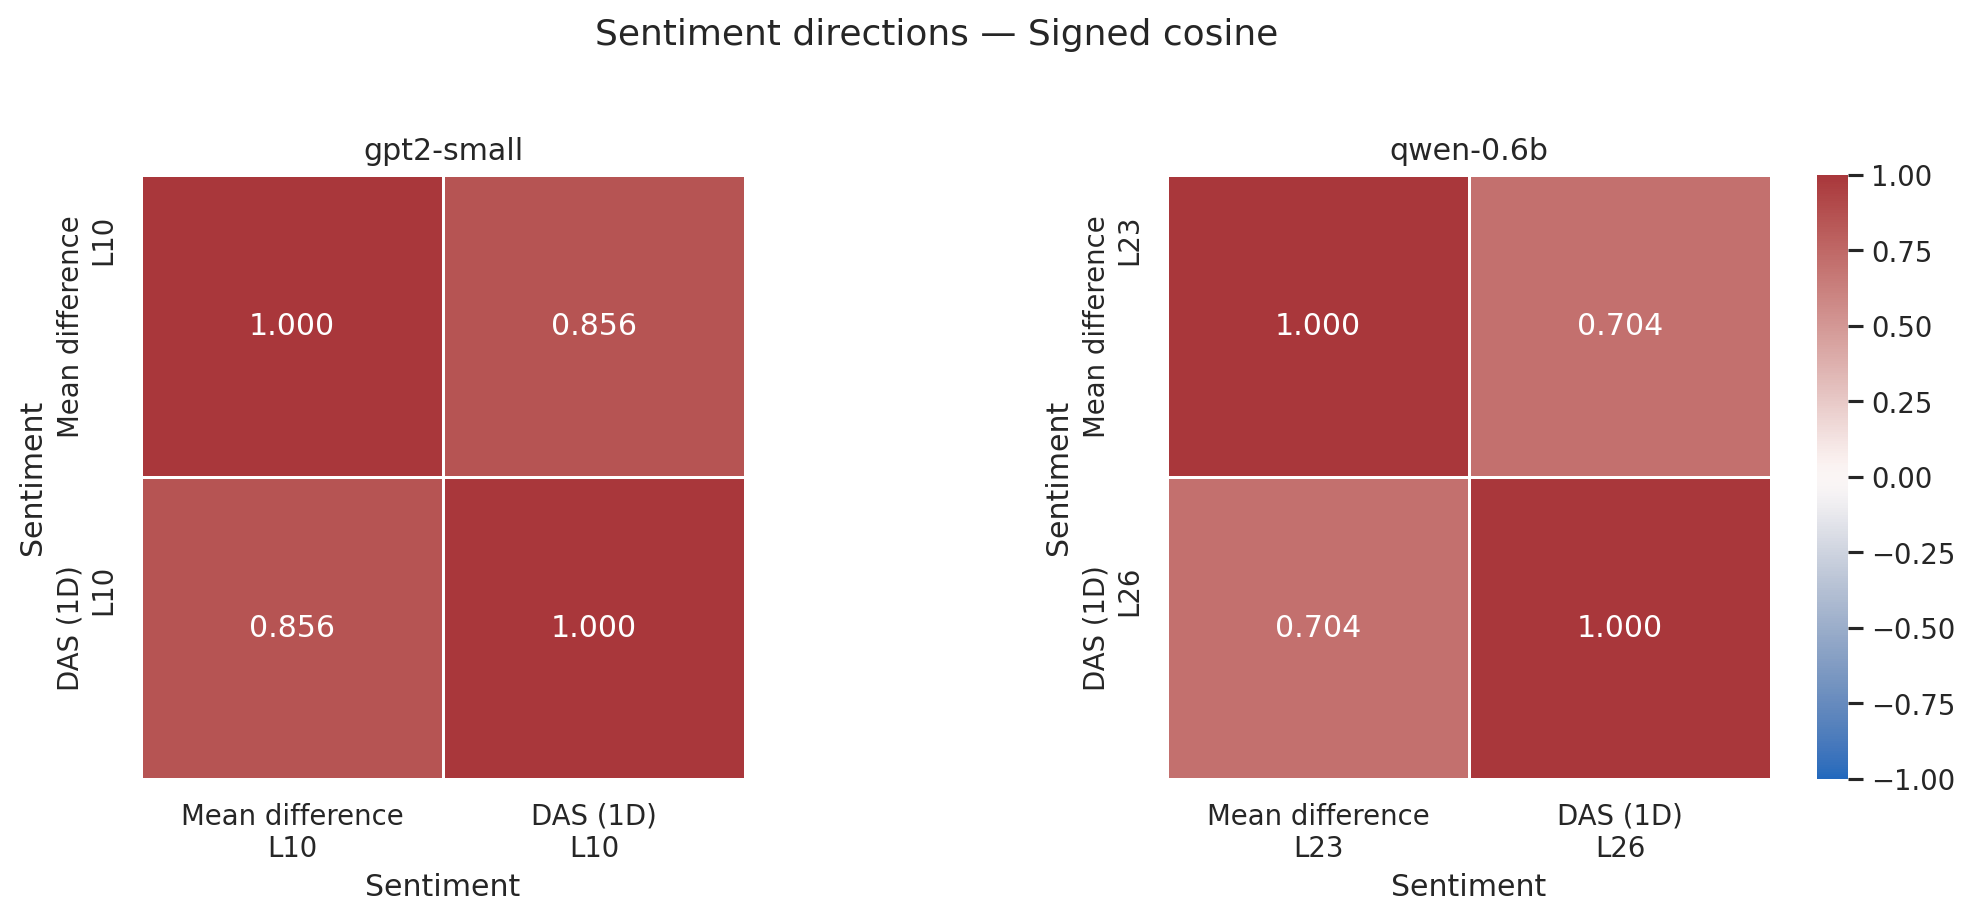

### Absolute Cosine Within Sentiment

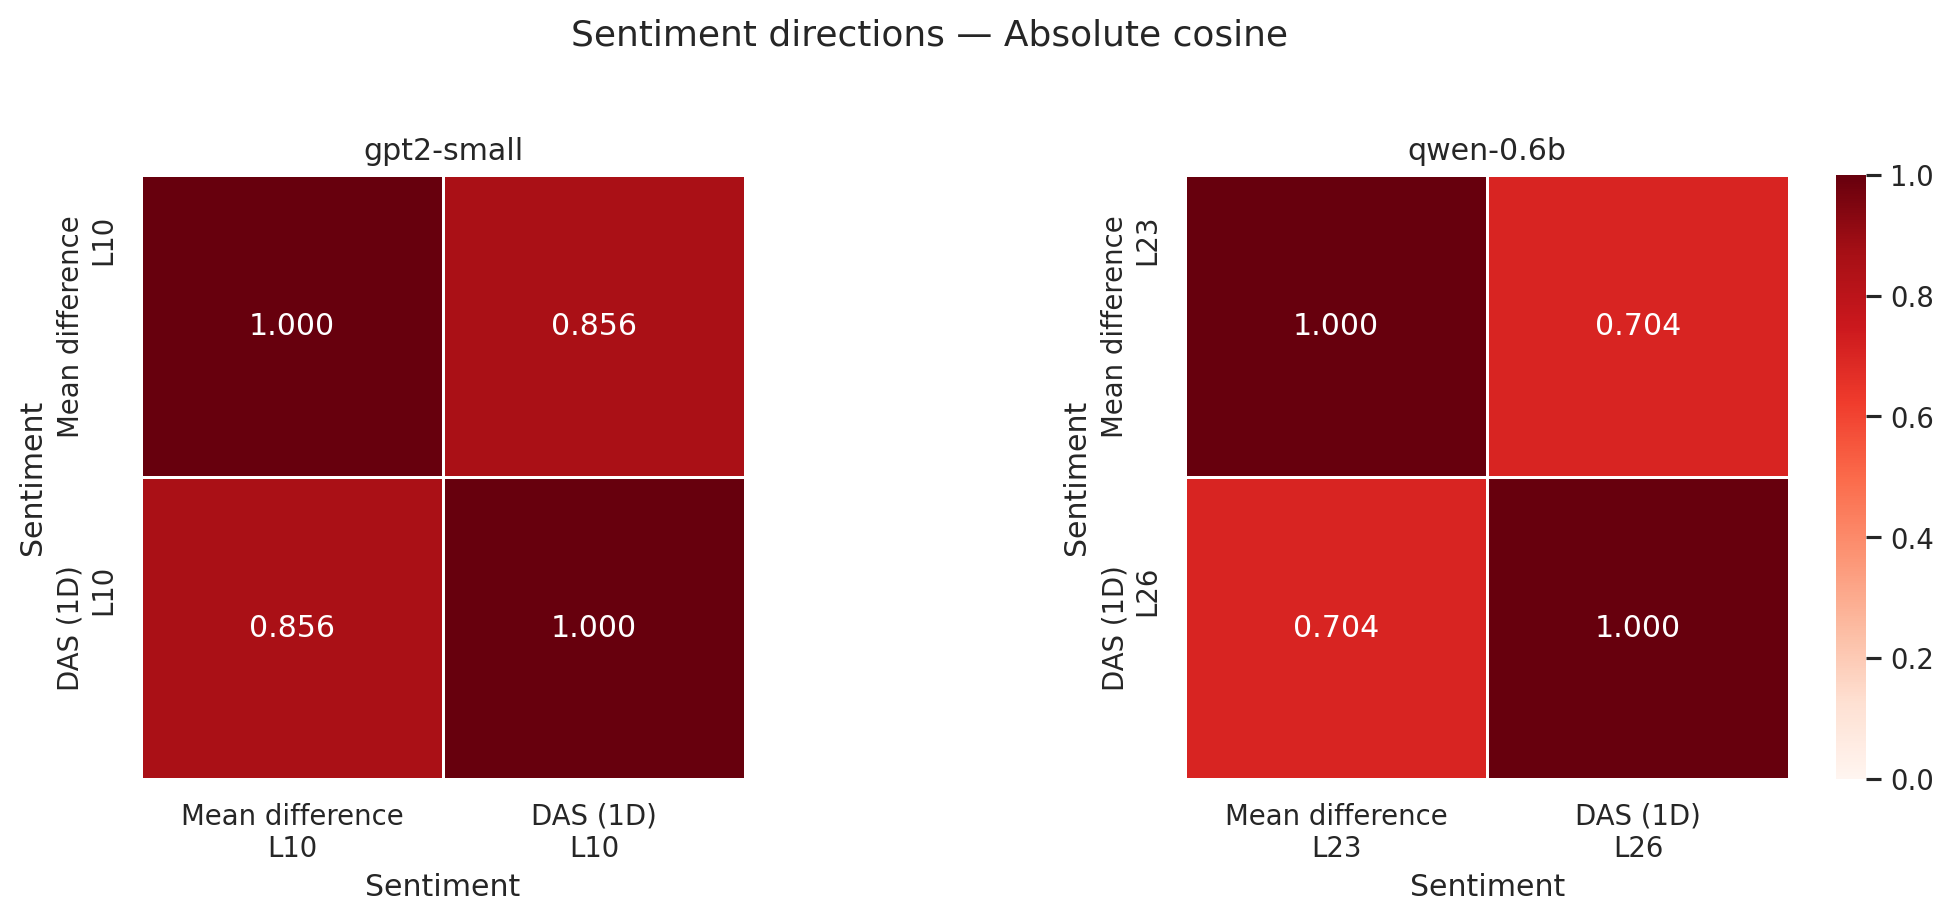

### Signed Cosine Within Valence

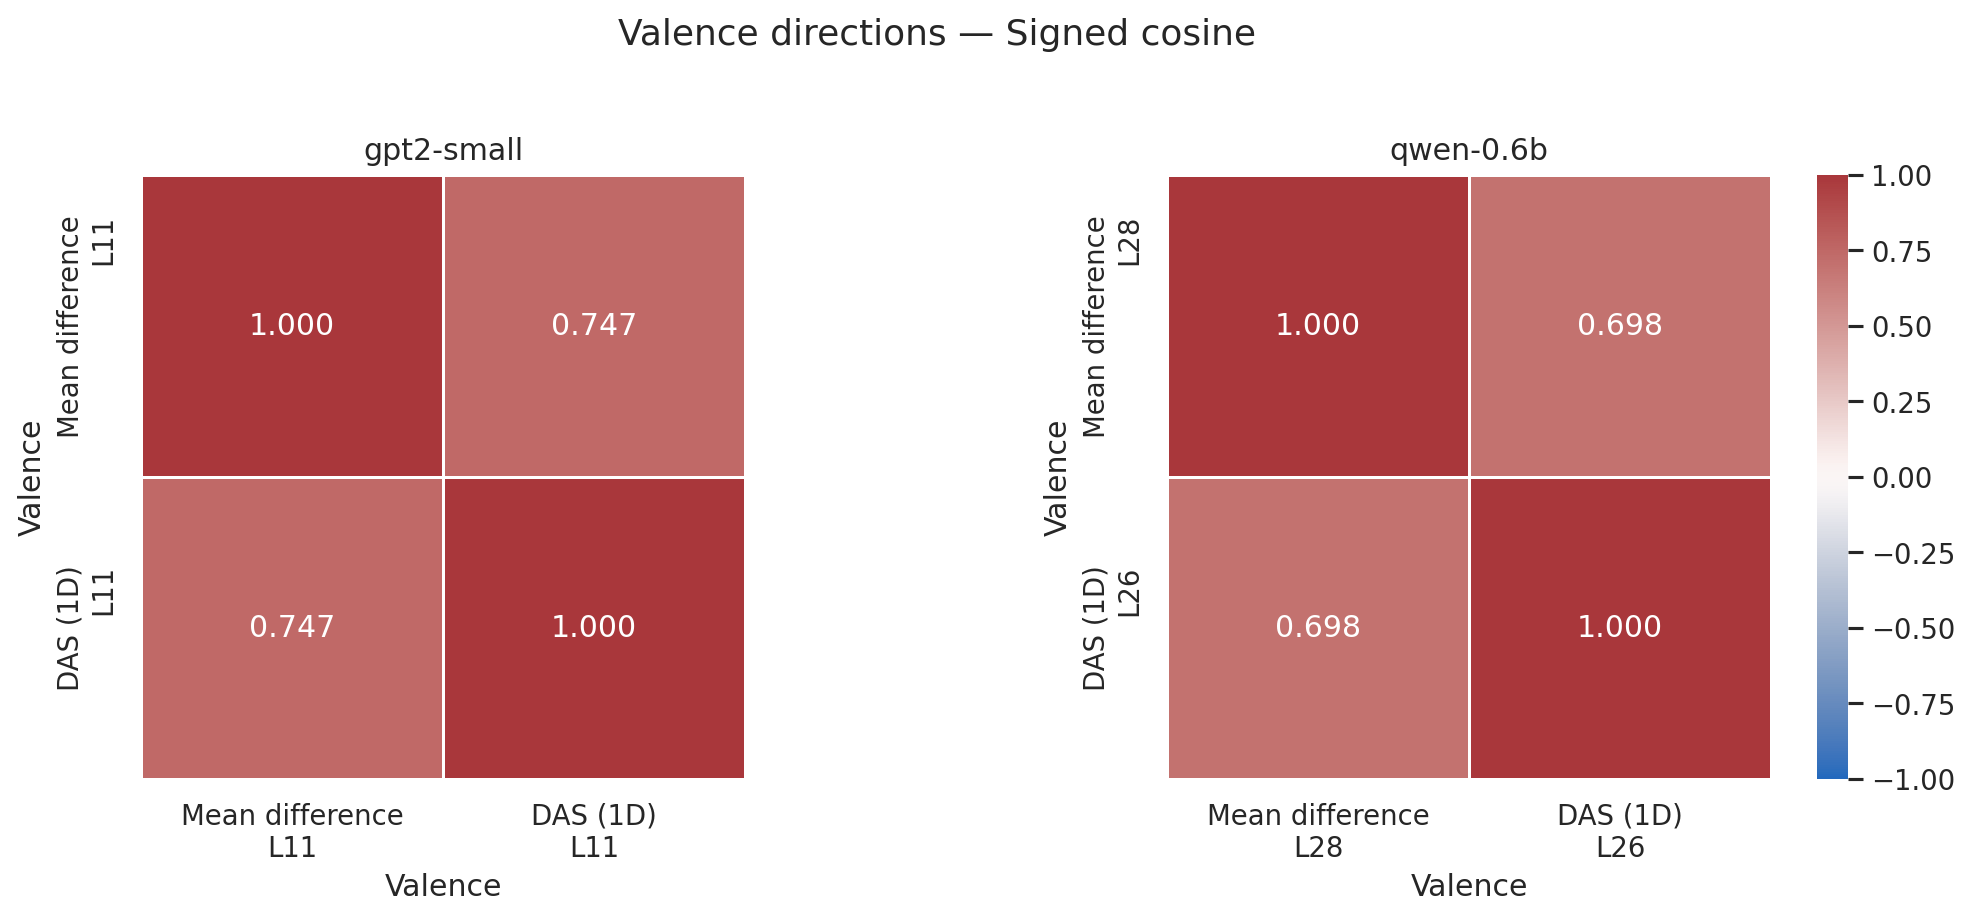

### Absolute Cosine Within Valence

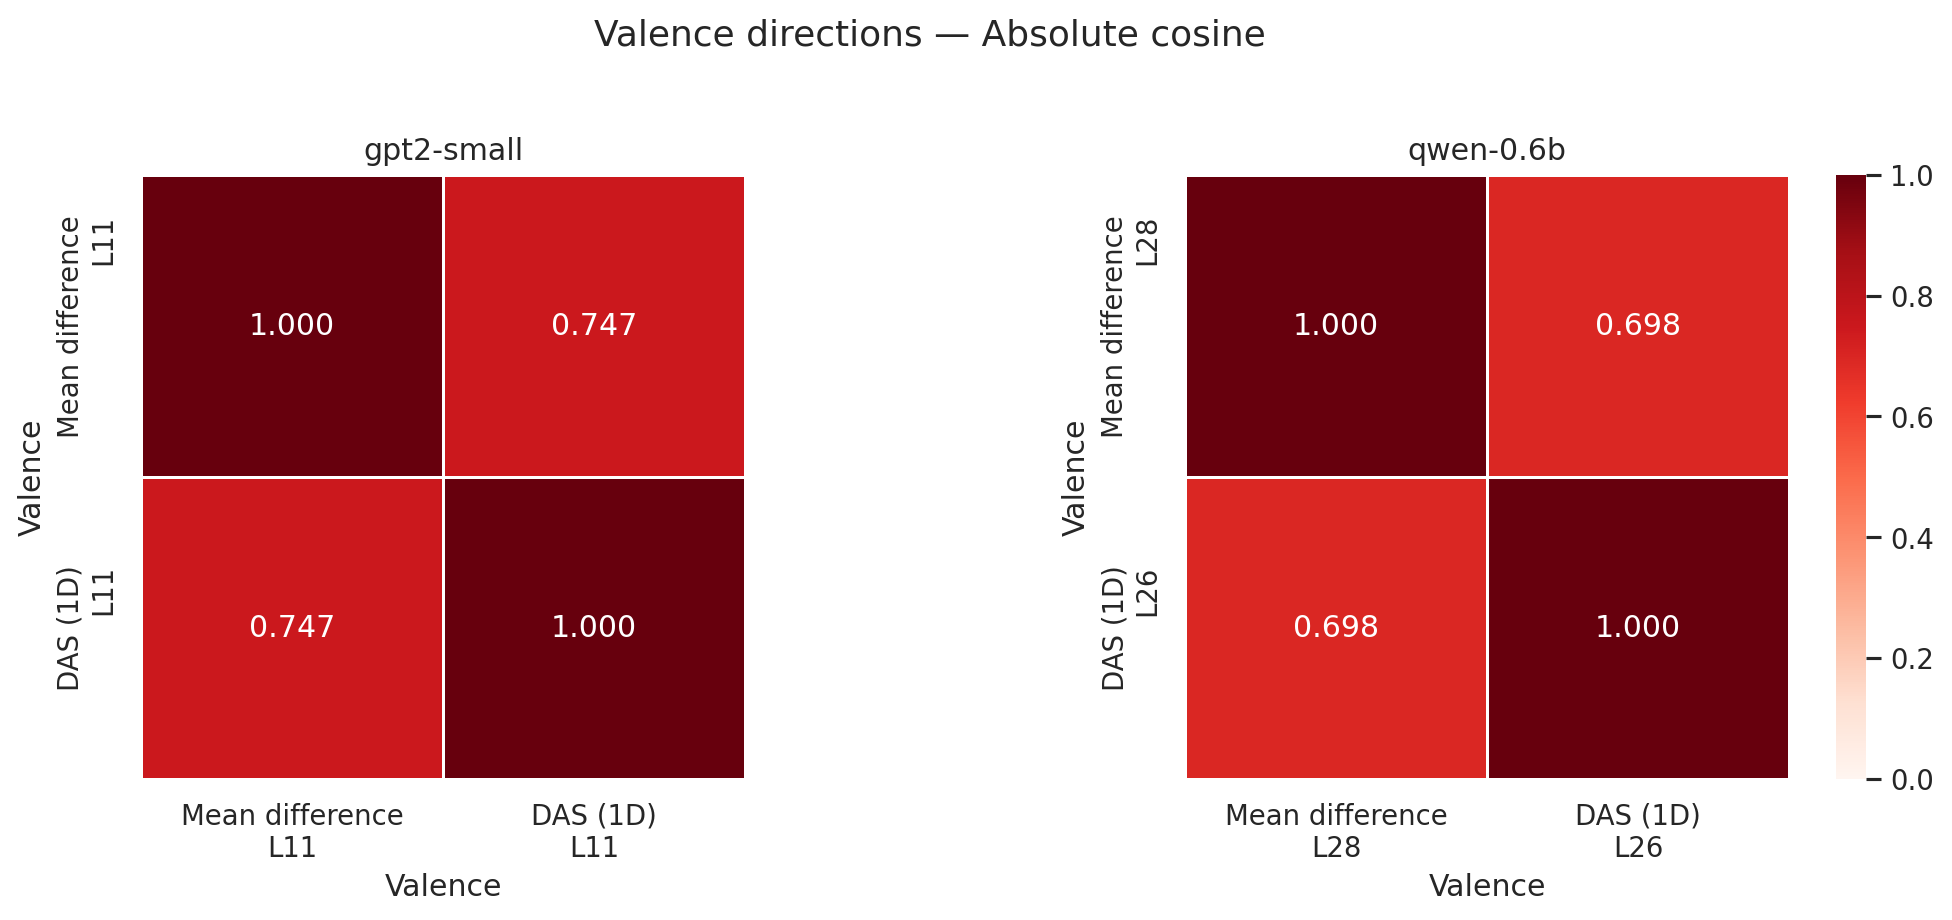

### Signed Cosine Valence Vs Sentiment

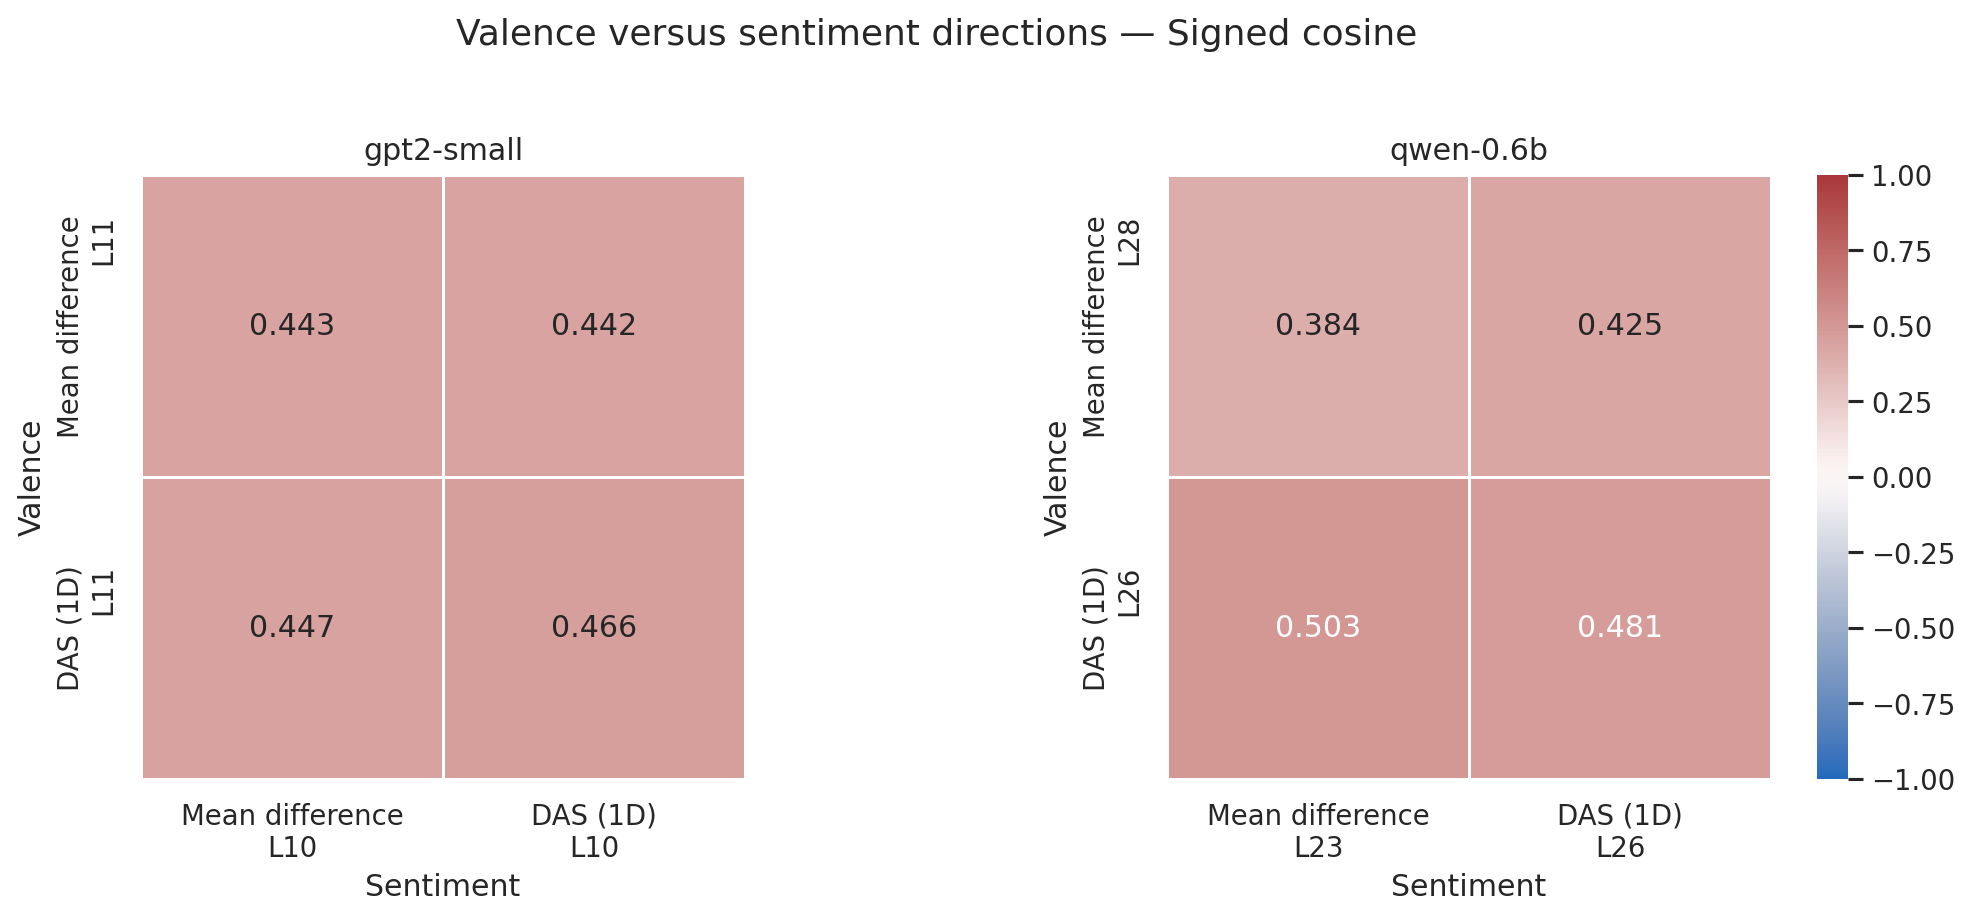

### Absolute Cosine Valence Vs Sentiment

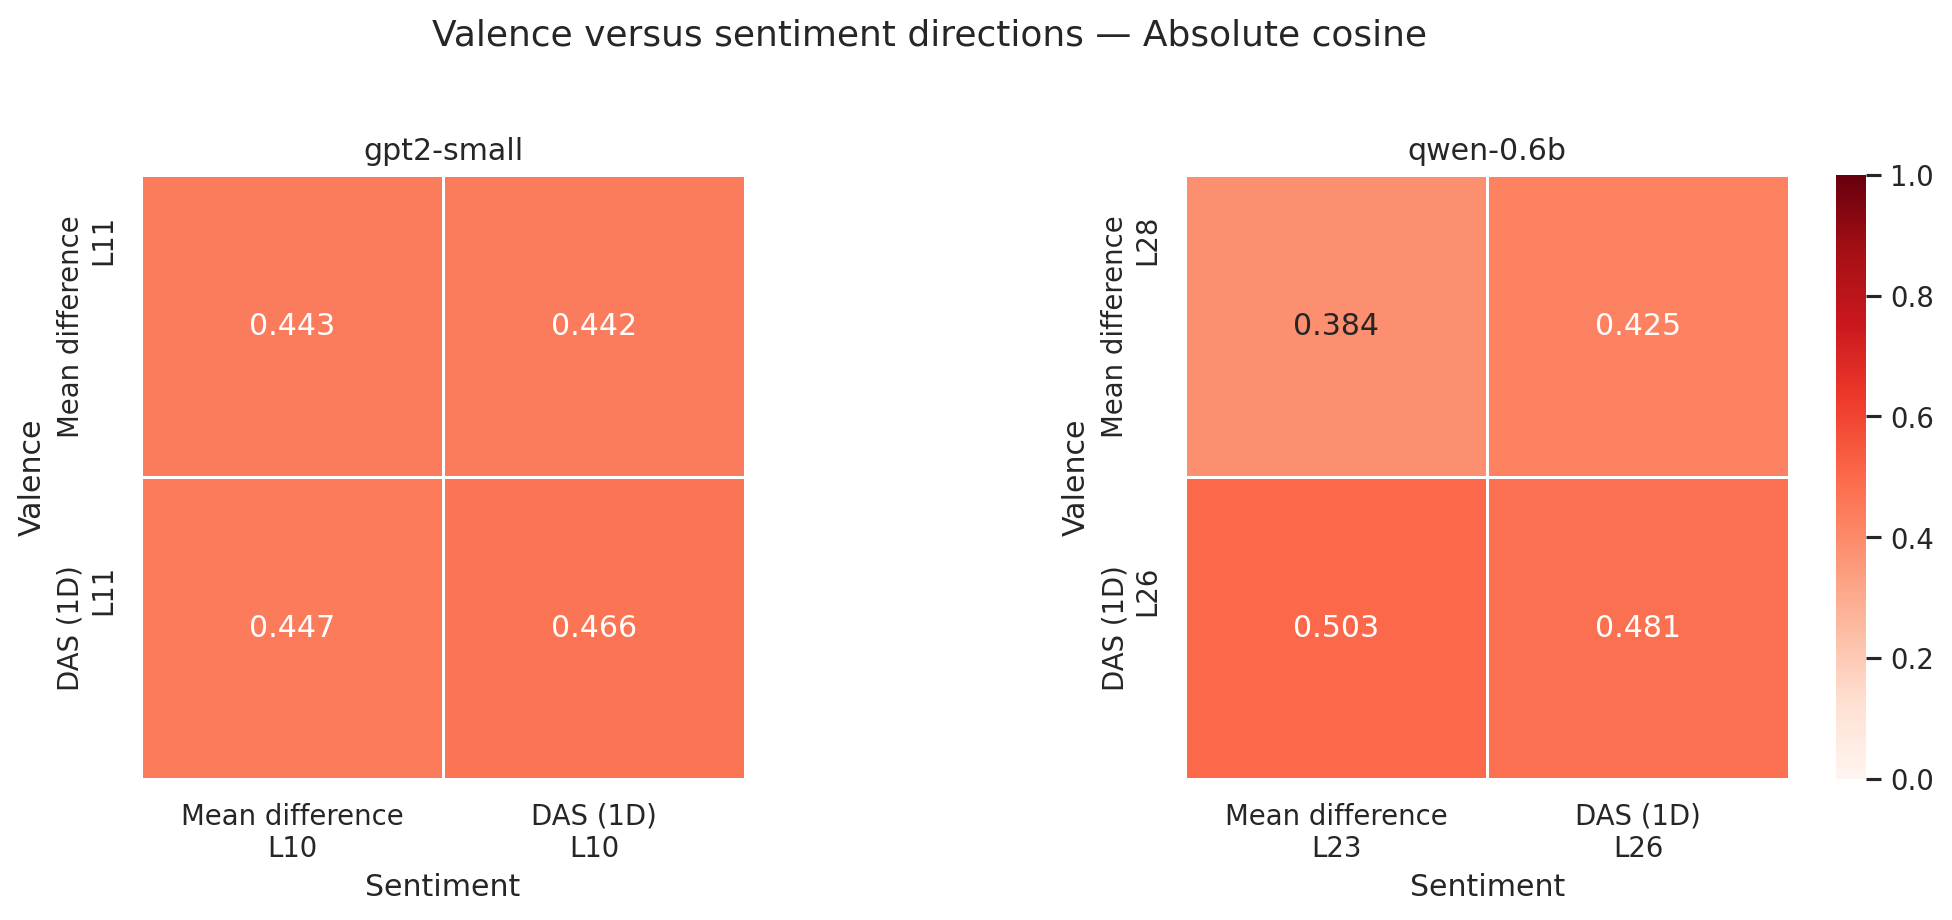

In [11]:
from IPython.display import Image

from sentiment_geometry.reporting import plot_direction_alignment

figure_paths = plot_direction_alignment(
    similarities,
    selections,
    figure_dir=RUN_LAYOUT.figures_dir,
    model_names=MODEL_ORDER,
    methods=METHOD_ORDER,
)
RunArtifactStore(RUN_LAYOUT.results_dir).write_rows(
    "figure_manifest.csv",
    [{"figure": path.name, "path": str(path)} for path in figure_paths],
)
for figure_path in figure_paths:
    display(Markdown(f"### {figure_path.stem.replace('_', ' ').title()}"))
    display(Image(filename=str(figure_path)))

## 7. Complete the exploration run

In [12]:
from datetime import datetime
from zoneinfo import ZoneInfo

completed_at = datetime.now(ZoneInfo(RUN_LAYOUT.timezone_name)).isoformat(timespec="minutes")
RUN_LAYOUT.update_manifest(
    status="completed",
    metadata={
        "completed_at": completed_at,
        "selected_direction_rows": len(selections),
        "cosine_rows": len(similarities),
        "same_method_rows": len(same_method),
        "figure_count": len(figure_paths),
    },
)
print("Completed run: ", RUN_LAYOUT.root)
print("Result tables: ", RUN_LAYOUT.results_dir)
print("Figures:       ", RUN_LAYOUT.figures_dir)
print("Manifest:      ", RUN_LAYOUT.manifest_path)

Completed run:  /content/drive/MyDrive/sentiment-geometry/sentiment-valence-direction-alignment/runs/2026-09-24_09-15_CDT
Result tables:  /content/drive/MyDrive/sentiment-geometry/sentiment-valence-direction-alignment/runs/2026-09-24_09-15_CDT/results
Figures:        /content/drive/MyDrive/sentiment-geometry/sentiment-valence-direction-alignment/runs/2026-09-24_09-15_CDT/figures
Manifest:       /content/drive/MyDrive/sentiment-geometry/sentiment-valence-direction-alignment/runs/2026-09-24_09-15_CDT/run_manifest.json


## Interpretation guide

- A signed cosine near `+1` means the two negative-to-positive directions point similarly.
- A signed cosine near `-1` means their axes align but their saved orientations oppose.
- An absolute cosine near `1` means strong one-dimensional axis alignment regardless of sign.
- A cosine near `0` means near-orthogonality in the residual-stream coordinate system.

These plots describe representational geometry only. A high cosine does not establish causal equivalence, shared computation, or interchangeability of the two directions; those claims require controlled cross-patching or steering experiments.